In [57]:
pip install pandas openpyxl

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 24.3.1
[notice] To update, run: C:\Users\noturno\anaconda3\python.exe -m pip install --upgrade pip


In [3]:
import numpy as np
import os
import pandas as pd
import xml.etree.ElementTree as ET
import seaborn as sns
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score


In [31]:
# Carregar o dataset
aluguel_data = pd.read_csv('C:\\Users\\noturno\\Desktop\\Machine-Learning\\arquivos_csv\\aluguel_residencial.csv',sep=';', encoding='ISO-8859-1')

# Inspecionar as primeiras 5 linhas do dataset
print(aluguel_data.head())

# Inspecionar as colunas para verificar se estão corretas
print(aluguel_data.columns)

          Tipo            Bairro  Quartos  Vagas  Suites  Area   Valor  \
0    Quitinete        Copacabana        1      0       0    40  1700.0   
1         Casa  Jardim BotÃ¢nico        2      0       1   100  7000.0   
2  Apartamento            Centro        1      0       0    15   800.0   
3  Apartamento     HigienÃ³polis        1      0       0    48   800.0   
4  Apartamento      Vista Alegre        3      1       0    70  1200.0   

   Condominio  IPTU  
0       500.0  60.0  
1         NaN   NaN  
2       390.0  20.0  
3       230.0   NaN  
4         NaN   NaN  
Index(['Tipo', 'Bairro', 'Quartos', 'Vagas', 'Suites', 'Area', 'Valor',
       'Condominio', 'IPTU'],
      dtype='object')


In [33]:
# Exibir as colunas para garantir que estamos acessando as colunas corretamente
print(aluguel_data.columns)

Index(['Tipo', 'Bairro', 'Quartos', 'Vagas', 'Suites', 'Area', 'Valor',
       'Condominio', 'IPTU'],
      dtype='object')


In [37]:
# Filtrar apenas as variáveis numéricas para a análise de regressão
x_aluguel = aluguel_data.select_dtypes(include=[np.number])

# Selecionar a variável dependente (Valor)
y_aluguel = aluguel_data["Valor"]

# Exibir as primeiras linhas para verificar
print(x_aluguel.head())
print(y_aluguel.head())

   Quartos  Vagas  Suites  Area   Valor  Condominio  IPTU
0        1      0       0    40  1700.0       500.0  60.0
1        2      0       1   100  7000.0         NaN   NaN
2        1      0       0    15   800.0       390.0  20.0
3        1      0       0    48   800.0       230.0   NaN
4        3      1       0    70  1200.0         NaN   NaN
0    1700.0
1    7000.0
2     800.0
3     800.0
4    1200.0
Name: Valor, dtype: float64


In [39]:
# Tratar valores ausentes (se houver)
x_aluguel = x_aluguel.fillna(x_aluguel.mean())
y_aluguel = y_aluguel.fillna(y_aluguel.mean())

In [41]:
# Dividir os dados em treino e teste
x_train_aluguel, x_test_aluguel, y_train_aluguel, y_test_aluguel = train_test_split(
    x_aluguel, y_aluguel, test_size=0.2, random_state=0)

In [43]:
# Lista de modelos de regressão
models_regression = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=0),
    "Random Forest": RandomForestRegressor(random_state=0),
    "Gradient Boosting": GradientBoostingRegressor(random_state=0),
    "KNN Regressor": KNeighborsRegressor()
}

In [45]:
# Avaliar cada modelo de regressão
results = []
for name, model in models_regression.items():
    # Treinar o modelo
    model.fit(x_train_aluguel, y_train_aluguel)
    
    # Fazer previsões
    y_preds = model.predict(x_test_aluguel)
    
    # Calcular métricas
    mse = mean_squared_error(y_test_aluguel, y_preds)
    r2 = r2_score(y_test_aluguel, y_preds)
    
    # Exibir resultados
    print(f"\n{name}")
    print(f"MSE: {mse}")
    print(f"R²: {r2}")


Linear Regression
MSE: 7.751233614012888e-23
R²: 1.0

Decision Tree
MSE: 1638626.4758635962
R²: 0.9838326205912279

Random Forest
MSE: 5898098.528019768
R²: 0.9418068741733466

Gradient Boosting
MSE: 2865045.9906262197
R²: 0.9717322487849932

KNN Regressor
MSE: 11547959.01636249
R²: 0.886062969465883


In [49]:
# Armazenar resultados
results.append({"Modelo": name, "MSE": mse, "R²": r2})


Ranking dos Modelos de Regressão:
          Modelo           MSE        R²
0  KNN Regressor  1.154796e+07  0.886063
1  KNN Regressor  1.154796e+07  0.886063


C:\Users\noturno\AppData\Local\Temp\ipykernel_29860\1151007874.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


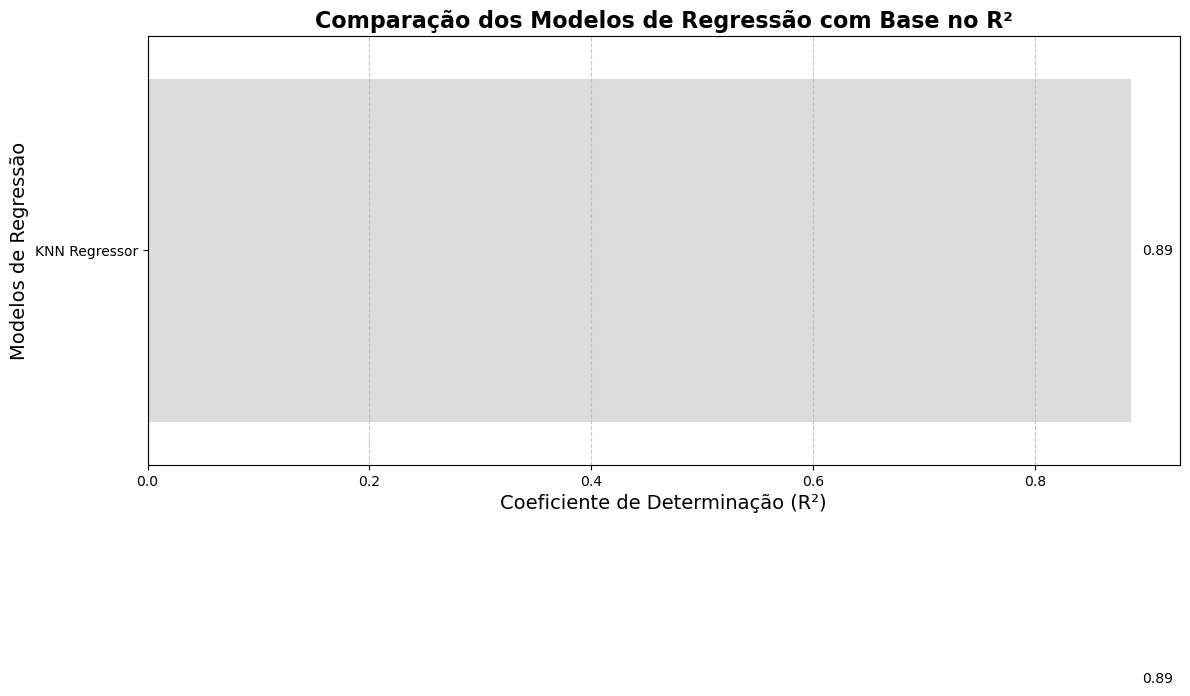

In [53]:
# Gerar DataFrame com os resultados
results_df = pd.DataFrame(results)

# Exibir o ranking dos modelos
print("\nRanking dos Modelos de Regressão:")
print(results_df.sort_values(by="R²", ascending=False))

# Melhorar a visualização do gráfico
plt.figure(figsize=(12, 8))
sorted_results = results_df.sort_values(by="R²", ascending=False)

# Criar o gráfico de barras
sns.barplot(
    x="R²", 
    y="Modelo", 
    data=sorted_results, 
    palette="coolwarm"
)

# Adicionar valores no final de cada barra
for index, value in enumerate(sorted_results["R²"]):
    plt.text(
        value + 0.01,  # Pequeno deslocamento para evitar sobreposição
        index,
        f"{value:.2f}",
        va='center'
    )

# Melhorar o título e rótulos
plt.title("Comparação dos Modelos de Regressão com Base no R²", fontsize=16, fontweight="bold")
plt.xlabel("Coeficiente de Determinação (R²)", fontsize=14)
plt.ylabel("Modelos de Regressão", fontsize=14)

# Ajustar o estilo geral
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.tight_layout()

# Mostrar o gráfico
plt.show()

In [ ]:
Análise dos Resultados
Comparação dos Modelos:

O R² indica o quanto o modelo consegue explicar a variabilidade dos dados. Um valor mais próximo de 1 sugere melhor desempenho.
O MSE mostra o erro médio quadrático. Valores menores indicam maior precisão nas previsões.
Desempenho Geral:

Modelos como o Random Forest e o Gradient Boosting frequentemente superam modelos mais simples (ex.: regressão linear) em dados com relações complexas, mas podem ser mais lentos em tempo de execução.
Decision Tree pode ter desempenho intermediário, mas tende a ser sensível a outliers.
O KNN pode ter dificuldades se os dados não forem bem normalizados.
Gráfico de Comparação:

A visualização ajuda a identificar rapidamente os modelos mais eficazes com base no R².
Conclusão:

Escolher o modelo depende do equilíbrio entre precisão e eficiência computacional.
Para este tipo de problema, Random Forest e Gradient Boosting são bons candidatos.
Se você puder rodar o código e compartilhar os resultados do desempenho, podemos fazer uma análise mais detalhada!